In [20]:
import sys
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA PyTorch:", torch.version.cuda)
print("CUDA disponibile:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: NESSUNA")

Python: C:\Users\Federico\MiniConda3\envs\ml2526\python.exe
PyTorch: 2.11.0+cu128
CUDA PyTorch: 12.8
CUDA disponibile: True
GPU: NVIDIA GeForce RTX 5060 Ti


In [21]:
from pathlib import Path
import shutil
import subprocess
import sys
import zipfile
import os

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

try:
    import gdown
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gdown"])
    import gdown


# =========================
# CONFIGURAZIONE PATH PROGETTO
# =========================

PROJECT_NAME = "MammoDiffusion"

# Lascia None se esegui il notebook dalla repo o dalla cartella notebooks/.
# Su Colab/Drive puoi impostare ad esempio:
# PROJECT_ROOT_OVERRIDE = "/content/drive/MyDrive/MammoDiffusion"
PROJECT_ROOT_OVERRIDE = None


def find_project_root(project_name=PROJECT_NAME, override=PROJECT_ROOT_OVERRIDE):
    """Trova automaticamente la root del progetto MammoDiffusion."""
    if override is not None:
        root = Path(override).expanduser().resolve()
        if not root.exists():
            raise FileNotFoundError(f"PROJECT_ROOT_OVERRIDE non esiste: {root}")
        return root

    cwd = Path.cwd().resolve()

    for candidate in [cwd, *cwd.parents]:
        if candidate.name == project_name:
            return candidate
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            return candidate

    for candidate in [
        cwd / project_name,
        Path("/content") / project_name,
        Path("/content/drive/MyDrive") / project_name,
        Path.home() / project_name,
        Path.home() / "Progetto" / project_name,
    ]:
        if candidate.exists():
            return candidate.resolve()

    raise FileNotFoundError(
        "Non riesco a trovare la root del progetto MammoDiffusion.\n"
        "Esegui il notebook dalla repo clonata oppure imposta PROJECT_ROOT_OVERRIDE."
    )


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "data"
DATA_ORIGINAL_DIR = DATA_DIR / "original"
DATA_PROCESSED_DIR = DATA_DIR / "processed"
ARCHIVES_DIR = DATA_DIR / "archives"
EXPERIMENTS_DIR = PROJECT_ROOT / "experiments"
RESULTS_DIR = PROJECT_ROOT / "results"

# Dataset aumentato già pronto, scaricato da Drive.
# Il file deve essere uno ZIP che contiene metadata.csv e le immagini.
# metadata.csv può avere già la colonna text oppure solo label: in quel caso text viene creata automaticamente.
AUGMENTED_DRIVE_ID = "1daVcSx8P2-iA55PEP58pGHkxnbZ2tFgg"
AUGMENTED_ZIP_PATH = ARCHIVES_DIR / "real_augmented.zip"
DATA_AUG = DATA_DIR / "real_augmented"
AUGMENTED_EXTRACT_TMP_DIR = DATA_DIR / "_real_augmented_extract_tmp"

# True = riscarica lo ZIP e riestrae tutto.
# False = se data/real_augmented è già pronta, non scarica e non estrae.
FORCE_AUGMENTED_REDOWNLOAD = False

for directory in [
    DATA_ORIGINAL_DIR,
    DATA_PROCESSED_DIR,
    ARCHIVES_DIR,
    DATA_AUG,
    EXPERIMENTS_DIR,
    RESULTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)


# Prompt condizionati dalle label
POSITIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer positive, "
    "malignant finding, suspicious lesion, medical imaging"
)

NEGATIVE_PROMPT = (
    "grayscale MLO mammogram, breast cancer negative, "
    "no malignant finding, normal screening mammogram, medical imaging"
)


def label_to_prompt(label):
    label = int(label)

    if label == 1:
        return POSITIVE_PROMPT

    if label == 0:
        return NEGATIVE_PROMPT

    raise ValueError(f"Label non valida: {label}")


print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_AUG:", DATA_AUG)
print("AUGMENTED_ZIP_PATH:", AUGMENTED_ZIP_PATH)

PROJECT_ROOT: D:\Progetto Deep\MammoDiffusion
DATA_AUG: D:\Progetto Deep\MammoDiffusion\data\real_augmented
AUGMENTED_ZIP_PATH: D:\Progetto Deep\MammoDiffusion\data\archives\real_augmented.zip


In [22]:
# Download / estrazione dataset aumentato da Drive
IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def count_images(folder):
    """Conta le immagini dentro una cartella, includendo eventuali sottocartelle."""
    folder = Path(folder)
    if not folder.is_dir():
        return 0

    return sum(
        1
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def list_images(folder):
    """Restituisce le immagini del dataset come path relativi ordinati."""
    folder = Path(folder)
    if not folder.is_dir():
        return []

    image_paths = [
        path.relative_to(folder).as_posix()
        for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    ]
    return sorted(image_paths)


def clear_dir(folder):
    """Svuota una cartella senza cancellare la cartella stessa."""
    folder = Path(folder)
    folder.mkdir(parents=True, exist_ok=True)

    for item in folder.iterdir():
        if item.is_dir():
            shutil.rmtree(item)
        else:
            item.unlink()


def infer_label_from_file_name(file_name):
    """
    Fallback: prova a ricavare la label dal nome file.
    Funziona con nomi tipo mammo_000001_label1.png o mammo_000001_label0.png.
    """
    name = str(file_name).lower()

    if "label1" in name or "_label_1" in name:
        return 1

    if "label0" in name or "_label_0" in name:
        return 0

    raise ValueError(f"Non riesco a ricavare la label dal nome file: {file_name}")


def metadata_has_existing_files(dataset_dir, metadata_df):
    """Controlla che almeno alcuni file indicati in metadata.csv esistano davvero."""
    if "file_name" not in metadata_df.columns:
        return False

    file_names = metadata_df["file_name"].dropna().astype(str).tolist()
    if not file_names:
        return False

    existing = 0

    for file_name in file_names[: min(100, len(file_names))]:
        file_name = file_name.replace("\\", "/")
        if (Path(dataset_dir) / file_name).exists():
            existing += 1

    return existing > 0


def create_metadata_from_existing_images(dataset_dir):
    """
    Crea metadata.csv partendo dalle immagini già presenti in data/real_augmented.
    Serve come fallback se la cartella contiene le immagini ma non contiene metadata.csv.
    """
    dataset_dir = Path(dataset_dir)
    image_files = list_images(dataset_dir)

    if not image_files:
        raise FileNotFoundError(f"Non trovo immagini in: {dataset_dir}")

    rows = []
    for file_name in image_files:
        label = infer_label_from_file_name(file_name)
        rows.append({
            "file_name": file_name,
            "label": label,
            "source": "existing_real_augmented",
            "text": label_to_prompt(label),
        })

    metadata_df = pd.DataFrame(rows)
    metadata_df.to_csv(dataset_dir / "metadata.csv", index=False)

    print("metadata.csv mancante: creato automaticamente dalle immagini già presenti.")
    print("metadata.csv:", dataset_dir / "metadata.csv")

    return metadata_df


def augmented_dataset_ready(dataset_dir):
    """
    True se data/real_augmented contiene:
    - immagini
    - metadata.csv valido, oppure immagini da cui metadata.csv può essere ricostruito
    """
    dataset_dir = Path(dataset_dir)

    if not dataset_dir.exists():
        return False

    if count_images(dataset_dir) == 0:
        return False

    metadata_path = dataset_dir / "metadata.csv"
    if not metadata_path.exists():
        # Se ci sono già le immagini, va comunque bene: il metadata verrà creato dopo.
        return True

    try:
        metadata_df = pd.read_csv(metadata_path)
    except Exception:
        return False

    if "file_name" not in metadata_df.columns:
        return False

    return metadata_has_existing_files(dataset_dir, metadata_df)


def download_augmented_zip():
    """
    Scarica real_augmented.zip da Drive solo se manca oppure se FORCE_AUGMENTED_REDOWNLOAD=True.
    """
    if AUGMENTED_ZIP_PATH.exists() and not FORCE_AUGMENTED_REDOWNLOAD:
        if zipfile.is_zipfile(AUGMENTED_ZIP_PATH):
            print("Archivio aumentato già presente, salto download:", AUGMENTED_ZIP_PATH)
            return

        print("Archivio aumentato presente ma non valido: lo riscarico.")
        AUGMENTED_ZIP_PATH.unlink()

    elif AUGMENTED_ZIP_PATH.exists():
        AUGMENTED_ZIP_PATH.unlink()

    print("Download dataset aumentato da Google Drive...")
    gdown.download(
        id=AUGMENTED_DRIVE_ID,
        output=str(AUGMENTED_ZIP_PATH),
        quiet=False,
    )

    if not AUGMENTED_ZIP_PATH.exists() or AUGMENTED_ZIP_PATH.stat().st_size == 0:
        raise RuntimeError(
            "Download fallito. Controlla che il file Drive sia condiviso con "
            "'Chiunque abbia il link'."
        )

    if not zipfile.is_zipfile(AUGMENTED_ZIP_PATH):
        raise RuntimeError(
            f"Il file scaricato non sembra uno ZIP valido: {AUGMENTED_ZIP_PATH}"
        )

    print("Download completato:", AUGMENTED_ZIP_PATH)


def find_augmented_root(extract_dir):
    """
    Trova la cartella estratta che contiene immagini e, se presente, metadata.csv.
    Funziona sia se lo ZIP contiene direttamente i file,
    sia se contiene una cartella interna tipo real_augmented/.
    """
    extract_dir = Path(extract_dir)

    candidates = [extract_dir]
    candidates.extend([p for p in extract_dir.rglob("*") if p.is_dir()])

    # Preferisco una cartella che abbia sia metadata.csv sia immagini.
    for candidate in candidates:
        if (candidate / "metadata.csv").exists() and count_images(candidate) > 0:
            return candidate

    # Fallback: se lo ZIP contiene solo immagini, uso quella cartella e creo metadata dopo.
    for candidate in candidates:
        if count_images(candidate) > 0:
            return candidate

    raise FileNotFoundError(
        "Lo ZIP è stato estratto, ma non trovo una cartella con immagini.\n"
        "Controlla che lo ZIP contenga il dataset aumentato creato dal notebook 02."
    )


def extract_augmented_zip():
    print("Estrazione temporanea di real_augmented.zip dentro:", AUGMENTED_EXTRACT_TMP_DIR)

    clear_dir(AUGMENTED_EXTRACT_TMP_DIR)

    with zipfile.ZipFile(AUGMENTED_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(AUGMENTED_EXTRACT_TMP_DIR)

    extracted_dataset_root = find_augmented_root(AUGMENTED_EXTRACT_TMP_DIR)

    print("Dataset aumentato trovato nello ZIP:", extracted_dataset_root)
    print("Copio il dataset finale in:", DATA_AUG)

    clear_dir(DATA_AUG)

    for item in extracted_dataset_root.iterdir():
        if item.name == "__MACOSX":
            continue

        destination = DATA_AUG / item.name

        if item.is_dir():
            shutil.copytree(item, destination)
        else:
            shutil.copy2(item, destination)

    shutil.rmtree(AUGMENTED_EXTRACT_TMP_DIR, ignore_errors=True)


def normalize_metadata_for_diffusers(dataset_dir):
    """
    Sistema metadata.csv per il training Diffusers.
    Serve almeno:
    - file_name: nome/relativo path immagine
    - text: prompt associato all'immagine

    Se metadata.csv manca ma le immagini sono già presenti, lo crea dai nomi file.
    Se text manca, viene creata a partire da label.
    """
    dataset_dir = Path(dataset_dir)
    metadata_path = dataset_dir / "metadata.csv"

    if not metadata_path.exists():
        metadata_df = create_metadata_from_existing_images(dataset_dir)
    else:
        metadata_df = pd.read_csv(metadata_path).copy()

    if "file_name" not in metadata_df.columns:
        raise ValueError(
            "metadata.csv deve contenere la colonna file_name.\n"
            "Nel notebook 02 deve essere salvata come metadata_rows con file_name."
        )

    metadata_df["file_name"] = (
        metadata_df["file_name"]
        .astype(str)
        .str.replace("\\", "/", regex=False)
    )

    if "label" not in metadata_df.columns:
        print("Colonna label mancante: provo a ricavarla dal nome file.")
        metadata_df["label"] = metadata_df["file_name"].apply(infer_label_from_file_name)

    metadata_df["label"] = metadata_df["label"].astype(int)

    if "text" not in metadata_df.columns:
        print("Colonna text mancante: la creo automaticamente da label.")
        metadata_df["text"] = metadata_df["label"].apply(label_to_prompt)

    missing_files = [
        file_name
        for file_name in metadata_df["file_name"].tolist()
        if not (dataset_dir / file_name).exists()
    ]

    if missing_files:
        print("Esempi file mancanti:", missing_files[:10])
        raise FileNotFoundError(
            f"{len(missing_files)} immagini indicate in metadata.csv non sono state trovate in {dataset_dir}."
        )

    # Salvo il metadata normalizzato, mantenendo anche eventuali colonne extra.
    metadata_df.to_csv(metadata_path, index=False)

    return metadata_df


def prepare_augmented_dataset():
    """
    Usa data/real_augmented se è già pronta.
    Altrimenti:
    1. controlla se data/archives/real_augmented.zip è già presente;
    2. se manca, lo scarica da Drive;
    3. lo estrae in data/real_augmented;
    4. normalizza metadata.csv per Diffusers.
    """
    if augmented_dataset_ready(DATA_AUG) and not FORCE_AUGMENTED_REDOWNLOAD:
        print("Dataset aumentato già presente in data/real_augmented: salto download ed estrazione.")
    else:
        download_augmented_zip()
        extract_augmented_zip()

    metadata_df = normalize_metadata_for_diffusers(DATA_AUG)

    print("Dataset aumentato pronto per Diffusers.")
    print("Cartella training:", DATA_AUG)
    print("metadata.csv:", DATA_AUG / "metadata.csv")
    print("Numero immagini:", count_images(DATA_AUG))
    print("\nDistribuzione label:")
    print(metadata_df["label"].value_counts().sort_index())

    if "source" in metadata_df.columns:
        print("\nDistribuzione source:")
        print(metadata_df["source"].value_counts())

    return DATA_AUG.resolve()


AUGMENTED_DATASET_ROOT = prepare_augmented_dataset()

# Questa variabile viene usata più sotto dal comando di fine-tuning.
# In questo modo il resto del fine-tuning resta invariato.
SD_TRAIN_DIR = AUGMENTED_DATASET_ROOT

print("\nSD_TRAIN_DIR:", SD_TRAIN_DIR)

Dataset aumentato già presente in data/real_augmented: salto download ed estrazione.
Dataset aumentato pronto per Diffusers.
Cartella training: D:\Progetto Deep\MammoDiffusion\data\real_augmented
metadata.csv: D:\Progetto Deep\MammoDiffusion\data\real_augmented\metadata.csv
Numero immagini: 3061

Distribuzione label:
label
0    1701
1    1360
Name: count, dtype: int64

Distribuzione source:
source
real                     2041
positive_augmentation    1020
Name: count, dtype: int64

SD_TRAIN_DIR: D:\Progetto Deep\MammoDiffusion\data\real_augmented


Prime righe metadata:


,file_name,label,patient_id,image_id,source,original_processed_path,text
0,mammo_000000_label1.png,1,8248,1228024526,real,D:\Progetto Deep\MammoDiffusion\data\processed...,"grayscale MLO mammogram, breast cancer positiv..."
1,mammo_000001_label1_aug0.png,1,8248,1228024526,positive_augmentation,D:\Progetto Deep\MammoDiffusion\data\processed...,"grayscale MLO mammogram, breast cancer positiv..."
2,mammo_000002_label1_aug1.png,1,8248,1228024526,positive_augmentation,D:\Progetto Deep\MammoDiffusion\data\processed...,"grayscale MLO mammogram, breast cancer positiv..."
3,mammo_000003_label1_aug2.png,1,8248,1228024526,positive_augmentation,D:\Progetto Deep\MammoDiffusion\data\processed...,"grayscale MLO mammogram, breast cancer positiv..."
4,mammo_000004_label0.png,0,32984,1893902734,real,D:\Progetto Deep\MammoDiffusion\data\processed...,"grayscale MLO mammogram, breast cancer negativ..."



Colonne metadata:
['file_name', 'label', 'patient_id', 'image_id', 'source', 'original_processed_path', 'text']

Distribuzione label:
label
0    1701
1    1360
Name: count, dtype: int64


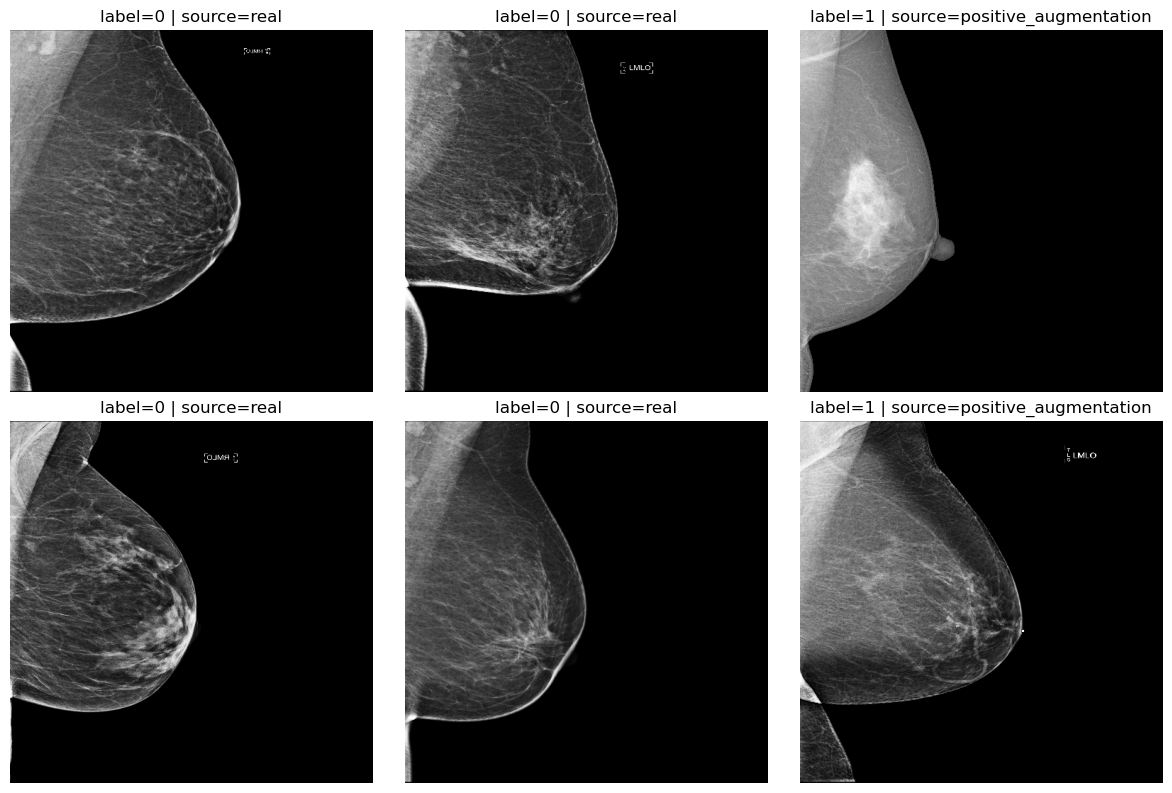

mammo_001765_label0.png | mode: L | size: (512, 512) | label: 0 | text: grayscale MLO mammogram, breast cancer negative, no malignant finding, normal screening mammogram, medical imaging
mammo_000203_label0.png | mode: L | size: (512, 512) | label: 0 | text: grayscale MLO mammogram, breast cancer negative, no malignant finding, normal screening mammogram, medical imaging
mammo_001356_label1_aug1.png | mode: L | size: (512, 512) | label: 1 | text: grayscale MLO mammogram, breast cancer positive, malignant finding, suspicious lesion, medical imaging
mammo_001451_label0.png | mode: L | size: (512, 512) | label: 0 | text: grayscale MLO mammogram, breast cancer negative, no malignant finding, normal screening mammogram, medical imaging
mammo_001577_label0.png | mode: L | size: (512, 512) | label: 0 | text: grayscale MLO mammogram, breast cancer negative, no malignant finding, normal screening mammogram, medical imaging
mammo_000102_label1_aug0.png | mode: L | size: (512, 512) | label: 1 | t

In [23]:
# Controllo rapido del dataset aumentato importato

metadata_sd_df = pd.read_csv(SD_TRAIN_DIR / "metadata.csv")

print("Prime righe metadata:")
display(metadata_sd_df.head())

print("\nColonne metadata:")
print(metadata_sd_df.columns.tolist())

print("\nDistribuzione label:")
print(metadata_sd_df["label"].value_counts().sort_index())

sample_df = metadata_sd_df.sample(min(6, len(metadata_sd_df)), random_state=42)

plt.figure(figsize=(12, 8))

for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    img_path = SD_TRAIN_DIR / row["file_name"]
    img = Image.open(img_path).convert("L")

    plt.subplot(2, 3, i)
    plt.imshow(img, cmap="gray")
    plt.title(f'label={row["label"]} | source={row.get("source", "n/a")}')
    plt.axis("off")

plt.tight_layout()
plt.show()

for _, row in sample_df.iterrows():
    img_path = SD_TRAIN_DIR / row["file_name"]
    img = Image.open(img_path)
    print(
        img_path.name,
        "| mode:", img.mode,
        "| size:", img.size,
        "| label:", row["label"],
        "| text:", row["text"]
    )


In [24]:
# Config fine-tuning StableDiffusion2.1

# Modello Stable Diffusion 2.1 scaricato da Drive.
# Zip contenente il modello Diffusers con model_index.json,
# unet/, vae/, text_encoder/, tokenizer/, scheduler/.
SD21_MODEL_DRIVE_ID = "10XRn-bxpp7tP6ROWLYpeCNYJZIaHfMUt"

FORCE_MODEL_REDOWNLOAD = False

# Cartelle di lavoro dentro la struttura MammoDiffusion.
EXPERIMENT_NAME = "20260607_sd21_rsna_mlo_512"
EXPERIMENT_DIR = EXPERIMENTS_DIR / EXPERIMENT_NAME

PRETRAINED_MODEL_DIR = EXPERIMENT_DIR / "pretrained_model" / "stable-diffusion-2-1-base"
PRETRAINED_MODEL_ZIP_PATH = EXPERIMENT_DIR / "archives" / "stable-diffusion-2-1-base.zip"
MODEL_EXTRACT_TMP_DIR = EXPERIMENT_DIR / "_model_extract_tmp"

SD_WORK_DIR = EXPERIMENT_DIR

# SD_TRAIN_DIR è già stato impostato al dataset aumentato importato da Drive.
# Deve puntare a data/real_augmented, che contiene metadata.csv e immagini.

DIFFUSERS_REPO_DIR = EXPERIMENT_DIR / "diffusers_repo"
HF_CACHE_DIR = EXPERIMENT_DIR / "hf_cache"

SD_OUTPUT_DIR = EXPERIMENT_DIR / "model"
LOGS_DIR = EXPERIMENT_DIR / "logs"
GENERATED_SAMPLES_DIR = EXPERIMENT_DIR / "generated_samples"
CONFIG_PATH = EXPERIMENT_DIR / "config.json"

MODEL_WEIGHT_ALIASES = {
    "text_encoder": {
        "source": "model.fp16.safetensors",
        "target": "model.safetensors",
    },
    "unet": {
        "source": "diffusion_pytorch_model.fp16.safetensors",
        "target": "diffusion_pytorch_model.safetensors",
    },
    "vae": {
        "source": "diffusion_pytorch_model.fp16.safetensors",
        "target": "diffusion_pytorch_model.safetensors",
    },
}

for directory in [
    EXPERIMENT_DIR,
    SD_DATASET_DIR,
    SD_TRAIN_DIR,
    HF_CACHE_DIR,
    SD_OUTPUT_DIR,
    LOGS_DIR,
    GENERATED_SAMPLES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("Modello locale:", PRETRAINED_MODEL_DIR)
print("Dataset training SD:", SD_TRAIN_DIR)
print("Output fine-tuning:", SD_OUTPUT_DIR)

Modello locale: D:\Progetto Deep\MammoDiffusion\experiments\20260607_sd21_rsna_mlo_512\pretrained_model\stable-diffusion-2-1-base
Dataset training SD: D:\Progetto Deep\MammoDiffusion\data\real_augmented
Output fine-tuning: D:\Progetto Deep\MammoDiffusion\experiments\20260607_sd21_rsna_mlo_512\model


In [25]:
def local_sd_model_ready(model_dir):
    """
    Controlla se il modello Stable Diffusion 2.1 locale è già estratto
    e ha i nomi dei pesi compatibili con Diffusers.
    """
    model_dir = Path(model_dir)

    required_paths = [
        model_dir / "model_index.json",
        model_dir / "scheduler",
        model_dir / "tokenizer",
        model_dir / "text_encoder",
        model_dir / "vae",
        model_dir / "unet",
        model_dir / "text_encoder" / "model.safetensors",
        model_dir / "unet" / "diffusion_pytorch_model.safetensors",
        model_dir / "vae" / "diffusion_pytorch_model.safetensors",
    ]

    return all(path.exists() for path in required_paths)
    

def has_diffusers_structure(model_dir):
    """
    Controlla solo la struttura base del modello Diffusers.
    Non controlla ancora i nomi finali dei pesi.
    """
    model_dir = Path(model_dir)

    required_paths = [
        model_dir / "model_index.json",
        model_dir / "scheduler",
        model_dir / "tokenizer",
        model_dir / "text_encoder",
        model_dir / "vae",
        model_dir / "unet",
    ]

    return all(path.exists() for path in required_paths)
    

def find_diffusers_model_dir(root_dir):
    """
    Cerca dentro una cartella estratta il punto in cui si trova davvero model_index.json.
    Serve perché lo zip potrebbe contenere direttamente i file del modello
    oppure una cartella intermedia.
    """
    root_dir = Path(root_dir)

    candidates = [root_dir]
    candidates.extend(path.parent for path in root_dir.rglob("model_index.json"))

    for candidate in candidates:
        if has_diffusers_structure(candidate):
            return candidate

    return None


def download_pretrained_model_zip():
    if PRETRAINED_MODEL_ZIP_PATH.exists() and not FORCE_MODEL_REDOWNLOAD:
        if zipfile.is_zipfile(PRETRAINED_MODEL_ZIP_PATH):
            print("Archivio modello già presente, salto download:", PRETRAINED_MODEL_ZIP_PATH)
            return
        print("Archivio modello presente ma non valido: lo riscarico.")
        PRETRAINED_MODEL_ZIP_PATH.unlink()

    elif PRETRAINED_MODEL_ZIP_PATH.exists():
        PRETRAINED_MODEL_ZIP_PATH.unlink()

    PRETRAINED_MODEL_ZIP_PATH.parent.mkdir(parents=True, exist_ok=True)

    print("Download del modello Stable Diffusion 2.1 da Google Drive...")
    gdown.download(
        id=SD21_MODEL_DRIVE_ID,
        output=str(PRETRAINED_MODEL_ZIP_PATH),
        quiet=False,
    )

    if not PRETRAINED_MODEL_ZIP_PATH.exists() or PRETRAINED_MODEL_ZIP_PATH.stat().st_size == 0:
        raise RuntimeError(
            "Download del modello fallito. Controlla che il file Drive sia condiviso con "
            "'Chiunque abbia il link'."
        )

    if not zipfile.is_zipfile(PRETRAINED_MODEL_ZIP_PATH):
        raise RuntimeError(f"Il file scaricato non sembra uno ZIP valido: {PRETRAINED_MODEL_ZIP_PATH}")

    print("Download modello completato:", PRETRAINED_MODEL_ZIP_PATH)


def extract_pretrained_model_zip():
    print("Estrazione del modello Stable Diffusion 2.1...")

    if MODEL_EXTRACT_TMP_DIR.exists():
        shutil.rmtree(MODEL_EXTRACT_TMP_DIR)

    MODEL_EXTRACT_TMP_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(PRETRAINED_MODEL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(MODEL_EXTRACT_TMP_DIR)

    extracted_model_dir = find_diffusers_model_dir(MODEL_EXTRACT_TMP_DIR)

    if extracted_model_dir is None:
        raise FileNotFoundError(
            "Lo zip è stato estratto, ma non trovo una struttura Diffusers valida.\n"
            "Mi aspetto model_index.json e le cartelle scheduler/, tokenizer/, "
            "text_encoder/, vae/, unet/."
        )

    PRETRAINED_MODEL_DIR.parent.mkdir(parents=True, exist_ok=True)

    if PRETRAINED_MODEL_DIR.exists():
        shutil.rmtree(PRETRAINED_MODEL_DIR)

    shutil.copytree(extracted_model_dir, PRETRAINED_MODEL_DIR)

    create_model_weight_aliases(PRETRAINED_MODEL_DIR, MODEL_WEIGHT_ALIASES)
    
    shutil.rmtree(MODEL_EXTRACT_TMP_DIR)
    
    print("Modello estratto in:", PRETRAINED_MODEL_DIR)

def create_model_weight_aliases(model_dir, aliases):
    """
    Crea automaticamente i nomi standard attesi da Diffusers
    partendo dai file fp16 presenti nel modello scaricato.

    Esempio:
    unet/diffusion_pytorch_model.fp16.safetensors
    -> unet/diffusion_pytorch_model.safetensors

    È replicabile: non modifica Drive, agisce solo sulla copia locale estratta.
    """
    model_dir = Path(model_dir)

    for subfolder, names in aliases.items():
        source_path = model_dir / subfolder / names["source"]
        target_path = model_dir / subfolder / names["target"]

        if target_path.exists():
            print(f"Alias già presente: {target_path.relative_to(model_dir)}")
            continue

        if not source_path.exists():
            raise FileNotFoundError(
                f"Non trovo il file sorgente fp16:\n{source_path}\n"
                f"Controlla il contenuto dello zip del modello."
            )

        try:
            target_path.symlink_to(source_path.name)
            print(
                f"Creato symlink: {target_path.relative_to(model_dir)} "
                f"-> {source_path.name}"
            )
        except OSError:
            shutil.copy2(source_path, target_path)
            print(
                f"Creato alias tramite copia: {target_path.relative_to(model_dir)}"
            )

def prepare_pretrained_model():
    """
    Usa il modello locale se già presente.
    Altrimenti scarica lo zip da Drive e lo estrae dentro experiments/.
    """
    if local_sd_model_ready(PRETRAINED_MODEL_DIR) and not FORCE_MODEL_REDOWNLOAD:
        print("Modello Stable Diffusion 2.1 già presente: salto download ed estrazione.")
        return PRETRAINED_MODEL_DIR.resolve()

    download_pretrained_model_zip()
    extract_pretrained_model_zip()

    if not local_sd_model_ready(PRETRAINED_MODEL_DIR):
        raise FileNotFoundError(
            "Il modello è stato estratto, ma la struttura finale non è valida."
        )

    print("Modello Stable Diffusion 2.1 pronto.")
    return PRETRAINED_MODEL_DIR.resolve()


LOCAL_MODEL_DIR = prepare_pretrained_model()

print("LOCAL_MODEL_DIR:", LOCAL_MODEL_DIR)

Modello Stable Diffusion 2.1 già presente: salto download ed estrazione.
LOCAL_MODEL_DIR: D:\Progetto Deep\MammoDiffusion\experiments\20260607_sd21_rsna_mlo_512\pretrained_model\stable-diffusion-2-1-base


In [26]:
# Setup Diffusers, necessario avere le librerie necessarie, aggiornate, pronte all'uso

# Installiamo solo i pacchetti necessari a Diffusers,
# evitando di aggiornare automaticamente torch/tensorflow/tensorboard.
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-U",
    "diffusers", "transformers", "accelerate", "datasets",
    "safetensors", "huggingface_hub", "xformers"
])

DIFFUSERS_REPO_DIR = EXPERIMENT_DIR / "diffusers_repo"

if not (DIFFUSERS_REPO_DIR / ".git").exists():
    subprocess.run(["git", "clone", "https://github.com/huggingface/diffusers", str(DIFFUSERS_REPO_DIR)], check=True)
else:
    print("Repository Diffusers già presente.")

# Installa Diffusers dal repository clonato
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q", "-e", str(DIFFUSERS_REPO_DIR)
])

TEXT_TO_IMAGE_DIR = DIFFUSERS_REPO_DIR / "examples" / "text_to_image"
TRAIN_SCRIPT = TEXT_TO_IMAGE_DIR / "train_text_to_image.py"
REQ_PATH = TEXT_TO_IMAGE_DIR / "requirements.txt"

if not TRAIN_SCRIPT.exists():
    raise FileNotFoundError(f"Script non trovato: {TRAIN_SCRIPT}")

# NON installiamo requirements.txt automaticamente,
# perché può aggiornare pacchetti e creare conflitti nell'ambiente corrente.
print("Script training:", TRAIN_SCRIPT)

Repository Diffusers già presente.
Script training: D:\Progetto Deep\MammoDiffusion\experiments\20260607_sd21_rsna_mlo_512\diffusers_repo\examples\text_to_image\train_text_to_image.py


In [27]:
# SILENZIA LOG INUTILI
os.environ["HF_HUB_VERBOSITY"] = "error"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["DIFFUSERS_VERBOSITY"] = "error"
os.environ["ACCELERATE_LOG_LEVEL"] = "error"
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Silenzia warning Python non importanti
os.environ["PYTHONWARNINGS"] = "ignore"

In [28]:
# Fine-tuning
RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 8
LEARNING_RATE = 1e-5
MAX_TRAIN_STEPS = 4000
CHECKPOINTING_STEPS = 500
CHECKPOINTS_TOTAL_LIMIT = 4

# None per partire da zero.
# "latest" per riprendere automaticamente dall'ultimo checkpoint.
RESUME_FROM_CHECKPOINT = None

cmd = [
    sys.executable, "-m", "accelerate.commands.launch",
    "--mixed_precision=fp16",
    "--num_processes=1",

    str(TRAIN_SCRIPT),

    "--pretrained_model_name_or_path", str(LOCAL_MODEL_DIR),
    "--train_data_dir", str(SD_TRAIN_DIR),
    "--image_column", "image",
    "--caption_column", "text",

    "--resolution", str(RESOLUTION),
    "--center_crop",

    "--train_batch_size", str(TRAIN_BATCH_SIZE),
    "--gradient_accumulation_steps", str(GRADIENT_ACCUMULATION_STEPS),
    "--gradient_checkpointing",
    #"--enable_xformers_memory_efficient_attention",

    "--max_train_steps", str(MAX_TRAIN_STEPS),
    "--learning_rate", str(LEARNING_RATE),
    "--lr_scheduler", "constant",
    "--lr_warmup_steps", "0",
    "--max_grad_norm", "1",
    "--use_8bit_adam",

    "--checkpointing_steps", str(CHECKPOINTING_STEPS),
    "--checkpoints_total_limit", str(CHECKPOINTS_TOTAL_LIMIT),

    "--validation_prompts", POSITIVE_PROMPT, NEGATIVE_PROMPT,
    "--validation_epochs", "5",

    "--seed", "42",
    "--cache_dir", str(HF_CACHE_DIR),
    "--output_dir", str(SD_OUTPUT_DIR),

    "--report_to", "tensorboard",
    "--logging_dir", str(SD_OUTPUT_DIR / "logs"),

    "--dataloader_num_workers", "0",
]

if RESUME_FROM_CHECKPOINT is not None:
    cmd.extend([
        "--resume_from_checkpoint", RESUME_FROM_CHECKPOINT
    ])

print("Comando fine-tuning:")
print(" ".join([str(x) for x in cmd]))

env = os.environ.copy()

env["HF_HUB_VERBOSITY"] = "error"
env["TRANSFORMERS_VERBOSITY"] = "error"
env["DIFFUSERS_VERBOSITY"] = "error"
env["ACCELERATE_LOG_LEVEL"] = "error"
env["TOKENIZERS_PARALLELISM"] = "false"
env["PYTHONWARNINGS"] = "ignore"
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

process = subprocess.Popen(
    cmd, env=env,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True, bufsize=1
)

for line in iter(process.stdout.readline, ""):
    print(line, end="", flush=True)

process.wait()

if process.returncode != 0:
    raise subprocess.CalledProcessError(process.returncode, cmd)

Comando fine-tuning:
C:\Users\Federico\MiniConda3\envs\ml2526\python.exe -m accelerate.commands.launch --mixed_precision=fp16 --num_processes=1 D:\Progetto Deep\MammoDiffusion\experiments\20260607_sd21_rsna_mlo_512\diffusers_repo\examples\text_to_image\train_text_to_image.py --pretrained_model_name_or_path D:\Progetto Deep\MammoDiffusion\experiments\20260607_sd21_rsna_mlo_512\pretrained_model\stable-diffusion-2-1-base --train_data_dir D:\Progetto Deep\MammoDiffusion\data\real_augmented --image_column image --caption_column text --resolution 512 --center_crop --train_batch_size 1 --gradient_accumulation_steps 8 --gradient_checkpointing --max_train_steps 4000 --learning_rate 1e-05 --lr_scheduler constant --lr_warmup_steps 0 --max_grad_norm 1 --use_8bit_adam --checkpointing_steps 500 --checkpoints_total_limit 4 --validation_prompts grayscale MLO mammogram, breast cancer positive, malignant finding, suspicious lesion, medical imaging grayscale MLO mammogram, breast cancer negative, no mali

KeyboardInterrupt: 